In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = sns.load_dataset("titanic")

# Offline backup
df.to_csv("titanic.csv", index=False)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
print(df.info())

print("\nShape")
print(df.shape)

print("\nSummary Statistics")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

Shape
(891, 15)

Summary Statistics
         survived      pclass         age       sibs

In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent.round(2)
})

print(missing_df)

             Missing Count  Missing Percentage
age                    177               19.87
embarked                 2                0.22
deck                   688               77.22
embark_town              2                0.22


In [7]:
df = df.dropna(subset=["embarked", "embark_town"])

In [8]:
df["age"] = df["age"].fillna(df["age"].median())

In [9]:
df.drop(columns=["deck"], inplace=True)

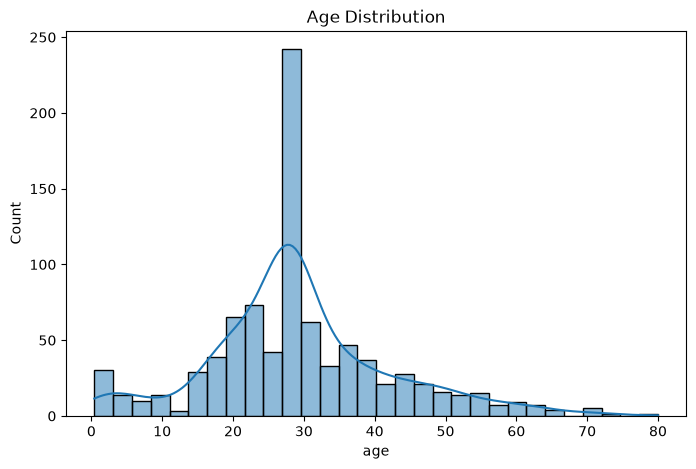

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

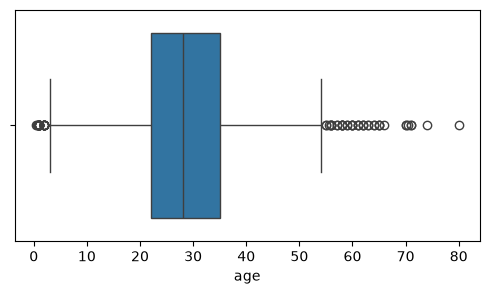

In [11]:
plt.figure(figsize=(6,3))

sns.boxplot(x=df["age"])

plt.show()

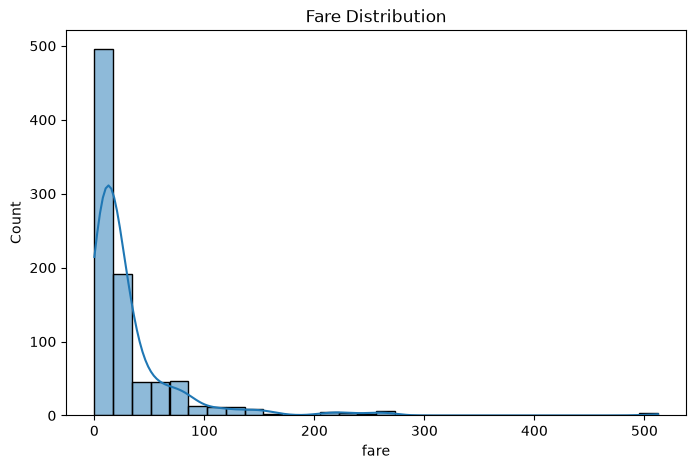

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["fare"], bins=30, kde=True)

plt.title("Fare Distribution")

plt.show()

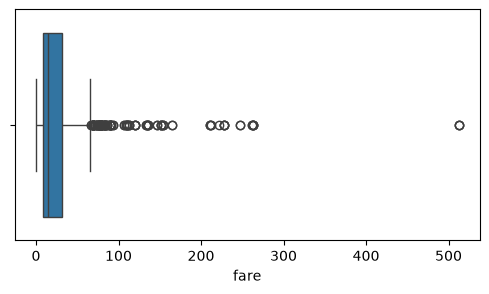

In [13]:
plt.figure(figsize=(6,3))

sns.boxplot(x=df["fare"])

plt.show()

In [14]:
def count_outliers(series):

    Q1 = series.quantile(0.25)

    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]

    return len(outliers)

In [15]:
print("Age Outliers :", count_outliers(df["age"]))

print("Fare Outliers :", count_outliers(df["fare"]))

Age Outliers : 65
Fare Outliers : 114


In [16]:
print("Mean :", df["fare"].mean())

print("Median :", df["fare"].median())

print("Mode :", df["fare"].mode()[0])

Mean : 32.09668087739032
Median : 14.4542
Mode : 8.05


since mean?median?mode , Fare is positively (right) skewed.

In [17]:
survival_sex = df.groupby("sex")["survived"].mean() * 100

print(survival_sex)

sex
female    74.038462
male      18.890815
Name: survived, dtype: float64


In [18]:
survival_class = df.groupby("pclass")["survived"].mean() * 100

print(survival_class)

pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64


In [19]:
survival_both = df.groupby(
    ["sex", "pclass"]
)["survived"].mean() * 100

print(survival_both)

sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64


In [20]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr = df[corr_columns].corr()

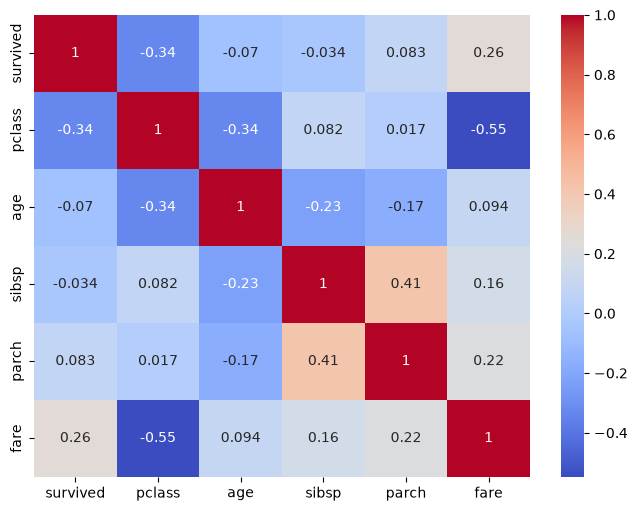

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [22]:
scaler = StandardScaler()

scaled = scaler.fit_transform(df[["age", "fare"]])

scaled_df = pd.DataFrame(
    scaled,
    columns=["age_scaled", "fare_scaled"]
)

print(scaled_df.describe())

         age_scaled   fare_scaled
count  8.890000e+02  8.890000e+02
mean   2.717486e-16  1.398706e-16
std    1.000563e+00  1.000563e+00
min   -2.226536e+00 -6.462044e-01
25%   -5.636741e-01 -4.872378e-01
50%   -1.013399e-01 -3.551972e-01
75%    4.380499e-01 -2.207954e-02
max    3.905556e+00  9.668551e+00
